# DSE Cal Adapt Climate Pipeline setup tutorial (w/ coiled version)

This notebook seeks to help you set up your environments, get coiled set up, and learn the insides of key functions, and then use my libraries built on top of CalAdapt's climatekitae!

## ToC

| Part | What | Time |
|------|------|------|
| **0** | Environment setup (run `setup.sh`) | ~5 min |
| **1** | Coiled setup | ~7 min |
| **2** | Fetch climate data with the library | 5 min |
| **3** | Understand key functions | 4 min |
| **4** | Exercise — fetch data for a new park | 10 min |
| **4.5** | Saving to CSV-- plotting in R, final summary | 5 min |

---

# Part 0: Environment Setup

**First time only.** If you've already run `setup.sh`, skip to Part 1.

## Option A: One-Command Setup (easier imo tbh)

Open a terminal, navigate to the DSE project folder, and run:

```bash
cd /path/to/DSE //(DSE being the root folder of this project, that's just what its called on my computer)
./setup.sh
```

This installs everything:
- `py-env` — Python environment with climakitae, xarray, geopandas, dask, coiled
- `r-env` — R environment with tidyverse, ggplot2, sf
- Jupyter configured to see both kernels

**Takes ~5 minutes.** 

## Option B: Manual Setup

If you prefer to do it step-by-step:

```bash
# Create Python environment
conda env create -f envs/py-env.yml

# Create R environment (optional)
conda env create -f envs/r-env.yml

# Set up Jupyter to see all conda environments
conda install -n base -c conda-forge nb_conda_kernels jupyterlab
```

---

## Verify Your Setup
Now that you're set up, in the top right corner, click py-env to set the python kernel.
Run the cell below. If it prints "Setup OK!", you're ready to go.

In [1]:
#setup check
import sys
import os

errors = []

# Check thre exist we can import key packages
try:
    import xarray
    print(f"✓ xarray {xarray.__version__}")
except ImportError:
    errors.append("xarray not installed")

try:
    import geopandas
    print(f"✓ geopandas {geopandas.__version__}")
except ImportError:
    errors.append("geopandas not installed")

try:
    import coiled
    print(f"✓ coiled installed")
except ImportError:
    errors.append("coiled not installed")

# Check library is accessible
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "lib"))

try:
    from andrewAdaptLibrary import CatalogExplorer, VARIABLE_MAP
    print(f"andrewAdaptLibrary imported")
    print(f"  Variables: {list(VARIABLE_MAP.keys())}")
except ImportError as e:
    errors.append(f"andrewAdaptLibrary: {e}")

# Check shapefiles exist
jt_path = os.path.join(PROJECT_ROOT, "parkOutlines", "JoshuaTree", "Joshua_Tree_National_Park.shp")
if os.path.exists(jt_path):
    print(f"Park shapefiles found")
else:
    errors.append("Park shapefiles not found")

print()
if errors:
    print("X SETUP ISSUES:")
    for e in errors:
        print(f"   - {e}")
    print("\nRun ./setup.sh from the DSE folder to fix.")
else:
    print(" yay! go to Part 1.")

✓ xarray 2025.11.0
✓ geopandas 1.1.2
✓ coiled installed
andrewAdaptLibrary imported
  Variables: ['T_Max', 'T_Min', 'Precip']
Park shapefiles found

 yay! go to Part 1.


---

# Part 1: Coiled Cloud Setup

**What is Coiled?** It spins up cloud machines (in AWS us-west-2) that are physically next to the climate data. This gives us **~67x speedup** vs running locally.

**Why us-west-2?** That's where Cal-Adapt's S3 bucket lives. Network latency from your laptop to Oregon is ~30ms. From an Oregon server to Oregon S3 is <1ms. That's the speedup (Maya from your question in 2/3 meeting)

**Cost?** We have free team seats. Compute is ~$0.04 for a typical test run for 5 years of data. We get $25 worth/motnh.

---

## Step 1: Login to Coiled (If you've done this already feel free to skip to Part 2)

Run this **in your terminal** (not notebook):

```bash
coiled login
```

A browser window opens. Log in with the email that was invited to my workspace.
Should be quick, just folllow the steps that come up. 

Then run cell below to verify:

In [2]:
import coiled

try:
    # This will fail if not logged in
    print("✓ Coiled is configured!")
    print(f"  View workspace: https://cloud.coiled.io")
except Exception as e:
    print(f" Not logged in: {e}")
    print("  Run 'coiled login' in your terminal first.")

✓ Coiled is configured!
  View workspace: https://cloud.coiled.io


## Step 2: Check Software Environment

The workspace has a software environment called `caladapt-env` with all the packages workers need. Let's double check it exists:

In [3]:

!coiled env list 2>/dev/null | grep -E "(caladapt|Name)" || echo "Run 'coiled login' first"

┃ Name         ┃ Updated                  ┃ Link                      ┃ Status ┃
│ caladapt-env │ 2026-02-04T07:09:05.553… │ https://cloud.coiled.io/… │ built  │


You should see `caladapt-env`. If not, ask me to debug, it's worked on other silicon comptuers, but if not ping me on slack. 

---

## Step 3: Test Cluster Launch

Spin up a tiny cluster to make sure everything works.

**First time takes ~2 minutes** (provisioning VMs). After that it's faster.

In [4]:
import coiled
from dask.distributed import Client
import time

print("Starting test cluster...")
print("(~2 min first time, faster after)")
print()
t0 = time.perf_counter()

cluster = coiled.Cluster(
    name="tutorial-test",              # name shows up in coiled dashboard
    region="us-west-2",                # same region as S3 bucket = fast transfers
    n_workers=1,                       # just 1 worker for this test
    worker_memory="8 GiB",             # memory per worker (limited options: 2,4,8,16,32 GiB)
    idle_timeout="5 minutes",          # auto-shutdown after 5 min idle (saves cpu hours)
    package_sync=True,                 # sync local packages to workers (builds env automatically)
)

# get_client() connects your local dask to the remote scheduler
client = cluster.get_client()
print(f"\n✓ Cluster ready in {time.perf_counter() - t0:.0f}s")
print(f"  Workers: {len(client.scheduler_info()['workers'])}")
print(f"  Dashboard: {client.dashboard_link}")  # click this to see task graph

Starting test cluster...
(~2 min first time, faster after)



/var/folders/pd/bmwwcgqd2h927m0s5tmbr5h40000gn/T/ipykernel_92667/2456336444.py:10: FutureWarning: `package_sync` is a deprecated kwarg for `Cluster` and will be removed in a future release. To only sync certain packages, use `package_sync_only`, and to disable package sync, pass the `container` or `software` kwargs instead.
  cluster = coiled.Cluster(
[2026-02-11 11:24:01,233][INFO    ][coiled] Fetching latest package priorities...
[2026-02-11 11:24:01,235][INFO    ][coiled.package_sync] Resolving your local py-env Python environment...
[2026-02-11 11:24:01,487][INFO    ][coiled.package_sync] Scanning 320 conda packages...
[2026-02-11 11:24:01,491][INFO    ][coiled.package_sync] Scanning 197 python packages...
[2026-02-11 11:24:02,040][INFO    ][coiled.software_utils] No username or password found for https://conda.anaconda.org/conda-forge
[2026-02-11 11:24:02,348][INFO    ][coiled] Running pip check...
[2026-02-11 11:24:02,650][INFO    ][coiled] Validating environment...
[2026-02-11 1


✓ Cluster ready in 161s
  Workers: 1
  Dashboard: https://cluster-igwpt.dask.host/rDDFlmeuEWEwP-Ps/status


In [5]:
# Run a simple task on the remote worker
import dask

@dask.delayed
def say_hello():
    import socket
    return f"Hello from {socket.gethostname()} in us-west-2!"

result = say_hello().compute()
print(result)
print("\n Coiled is working!")

Hello from ip-10-0-53-73 in us-west-2!

 Coiled is working!


In [6]:
# Always shut down when done- so we conserve coield credits and so i don't get charged on AWS a load  🌝
cluster.close()
print("Cluster shut down. 🌝")

[2026-02-11 11:27:32,149][INFO    ][coiled] Cluster 1433052 deleted successfully.


Cluster shut down. 🌝


---

## Part 1 Done 😎 🦎

So far:
- Logged into Coiled
- Verified the software environment
- Launched a test cluster

**Also once you've done this, you won't even needa to redo this** — Coiled remembers login.

---

# Part 2: Fetching Climate Data 🪝

Now let's get some real data from CalAdapt. We'll look at my library functions which abstract away some of the confusingness of climatekitae, and then peek into the hood later. 

## Step 1: Import some of my Library

In [7]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "lib"))

from andrewAdaptLibrary import (
    CatalogExplorer,                          # get what data exists
    load_boundary, get_lat_lon_bounds,        # work w/ shapefiles
    get_climate_data,                         # Main data fetching function
    VARIABLE_MAP, SCENARIO_MAP,               # Human-readable mappings
)

print("Library loaded!")
print(f"Variables: {list(VARIABLE_MAP.keys())}")
print(f"Scenarios: {list(SCENARIO_MAP.keys())}")

Library loaded!
Variables: ['T_Max', 'T_Min', 'Precip']
Scenarios: ['Historical Climate', 'SSP 2-4.5', 'SSP 3-7.0', 'SSP 5-8.5']


## Step 2: Quickly see What we have Avaliable Exists

`CatalogExplorer` queries the **live** Cal-Adapt catalog. I suppose that this is pretty nice since Cal-Adapt is changes their sstuff once and a while, this actually pulls the live data. This is from the Andrew library. The naïve way I suppose is just hardcoding everything-- but I think this will stand the test of time a little better.

In [8]:
cat = CatalogExplorer()
print(cat)
print()

print("Available at 3km monthly resolution:")
print(f"  Variables: {len(cat.variables())}")
print(f"  Scenarios: {len(cat.scenarios())}")
print(f"  Total Zarr stores: {cat.catalog_size}")

CatalogExplorer(activity='LOCA2', timescale='monthly', grid='d03', stores=1585)

Available at 3km monthly resolution:
  Variables: 10
  Scenarios: 4
  Total Zarr stores: 1585


In [9]:
# How many simulations per variable x scenario?
summary = cat.summary()

# make it prettier
summary.columns = ["Historical", "SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]
summary.index.name = "Variable"

# rename the variable IDs to eay to rread names
var_names = {
    "tasmax": "Max Temp",
    "tasmin": "Min Temp", 
    "pr": "Precip",
    "hursmax": "Max Humidity",
    "hursmin": "Min Humidity",
    "huss": "Specific Humidity",
    "rsds": "Solar Radiation",
    "uas": "Wind (E-W)",
    "vas": "Wind (N-S)",
    "wspeed": "Wind Speed",
}
summary.index = summary.index.map(lambda x: var_names.get(x, x))

summary.style.set_caption("Simulations available per variable × scenario")
#oh also Lucia and Maya, one thing I find strange is why there are different numbers of sumulations per var per scenario, but I'm not sure if this is sort of common?

,Historical,SSP 2-4.5,SSP 3-7.0,SSP 5-8.5
Variable,,,,
Max Humidity,51,25,45,25
Min Humidity,51,25,45,25
Specific Humidity,48,24,45,22
Precip,70,33,62,34
Solar Radiation,51,30,45,29
Max Temp,70,33,62,34
Min Temp,70,33,62,34
Wind (E-W),46,24,38,26
Wind (N-S),46,24,38,26


In [10]:
# Which climate GCMs are available?
gcms = cat.gcms("tasmax", "historical")
print(f"{len(gcms)} GCMs for tasmax/historical:")
for gcm in gcms:
    print(f"  - {gcm}")

15 GCMs for tasmax/historical:
  - ACCESS-CM2
  - CESM2-LENS
  - CNRM-ESM2-1
  - EC-Earth3
  - EC-Earth3-Veg
  - FGOALS-g3
  - GFDL-ESM4
  - HadGEM3-GC31-LL
  - INM-CM5-0
  - IPSL-CM6A-LR
  - KACE-1-0-G
  - MIROC6
  - MPI-ESM1-2-HR
  - MRI-ESM2-0
  - TaiESM1


## Step 3: Load area Study Area

In [11]:
# Load Joshua Tree National Park boundary
shapefile = os.path.join(PROJECT_ROOT, "parkOutlines", "JoshuaTree", "Joshua_Tree_National_Park.shp")
boundary = load_boundary(shapefile)

print(f"Loaded: {len(boundary)} polygon(s)")
print(f"CRS: {boundary.crs}")

lat_bounds, lon_bounds = get_lat_lon_bounds(boundary)
print(f"Latitude:  {lat_bounds[0]:.2f}°N to {lat_bounds[1]:.2f}°N")
print(f"Longitude: {abs(lon_bounds[0]):.2f}°W to {abs(lon_bounds[1]):.2f}°W")

Loaded: 1 polygon(s)
CRS: EPSG:4326
Latitude:  33.67°N to 34.13°N
Longitude: 116.46°W to 115.26°W


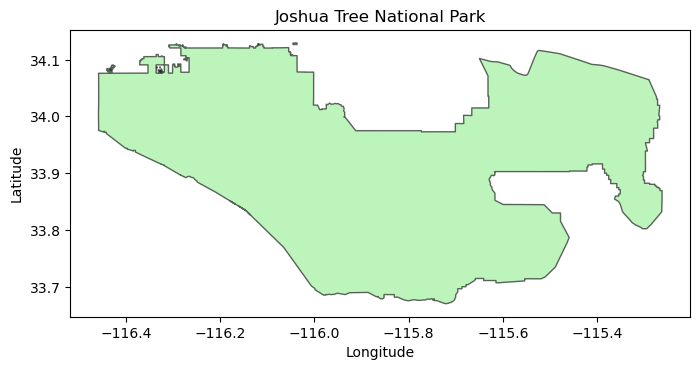

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
boundary.plot(ax=ax, edgecolor="black", facecolor="lightgreen", alpha=0.6)
ax.set_title("Joshua Tree National Park")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## Step 4: Fetch Data with Coiled

Okay the real stuff. Here's the flow:

1. **Start cluster** → spins up workers in us-west-2 (same region as the data)
2. **Call `get_climate_data()`** → workers fetch from S3, clip to your boundary, compute spatial averages
3. **Get back DataFrames** → results come back to your laptop as pandas DataFrames (in memory, not saved to disk)
4. **Shut down cluster** → important so you don't burn credits

For 3 variables × 70 simulations × 5 years: **~1.5 min** with Coiled vs **~30 min** locally.

In [13]:
import coiled
import time
#this just starts the cluster btw... no cal_adapt stuff. Also, note that even though this takes only a few minutes, if you leave it idle (as in don't run the next cells) it'll shut down.
print("Starting cluster...")
t0 = time.perf_counter()

cluster = coiled.Cluster(
    name="tutorial-fetch",
    region="us-west-2",                # where the data lives (cadcat S3 bucket)
    n_workers=3,                       # 3 workers = fetch 3 vars in parallel
    worker_memory="8 GiB",             # each worker gets 8 GiB RAM
    spot_policy="spot_with_fallback",  # use spot instances (cheaper), fall back to on-demand if unavailable
    idle_timeout="5 minutes",          # shut down if idle (don't waste credits)
    package_sync=True,                 # sync local packages to workers (builds env automatically)
)

# this connects local python session to the remote scheduler
# all dask operations now run on the cluster, not laptop!
client = cluster.get_client()
print(f"\n✓ Ready in {time.perf_counter() - t0:.0f}s")
print(f"  Dashboard: {client.dashboard_link}")

Starting cluster...


/var/folders/pd/bmwwcgqd2h927m0s5tmbr5h40000gn/T/ipykernel_92667/4270335290.py:7: FutureWarning: `package_sync` is a deprecated kwarg for `Cluster` and will be removed in a future release. To only sync certain packages, use `package_sync_only`, and to disable package sync, pass the `container` or `software` kwargs instead.
  cluster = coiled.Cluster(
[2026-02-11 11:27:39,971][INFO    ][coiled] Fetching latest package priorities...
[2026-02-11 11:27:39,972][INFO    ][coiled.package_sync] Resolving your local py-env Python environment...
[2026-02-11 11:27:40,224][INFO    ][coiled.package_sync] Scanning 320 conda packages...
[2026-02-11 11:27:40,228][INFO    ][coiled.package_sync] Scanning 197 python packages...
[2026-02-11 11:27:40,492][INFO    ][coiled] Running pip check...
[2026-02-11 11:27:40,837][INFO    ][coiled] Validating environment...
[2026-02-11 11:27:41,318][INFO    ][coiled] Creating wheel for ~/Desktop/DSE/lib...
[2026-02-11 11:27:41,329][INFO    ][coiled] Creating wheel for


✓ Ready in 136s
  Dashboard: https://cluster-mmbyp.dask.host/aFTEOE2bPAEGNEpD/status


In [14]:
# Fetch climate data using my library wrapper around calAdapt
# this gives work to the remote workers, they do the heavy lifting
print("Fetching data...")
t0 = time.perf_counter()

data = get_climate_data(
    variables=["T_Max", "T_Min", "Precip"],  # human-readable names (mapped to tasmax, tasmin, pr)
    scenarios=["Historical Climate"],         # mapped to "historical" experiment_id, all four would be: scenarios=["Historical Climate", "SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]
    boundary=boundary,                        # GeoDataFrame gets serialized to WKT automatically
    time_slice=(2010, 2014),                  # 5 years for demo-- keep it small to save credits
    timescale="monthly",                      # "monthly", "daily", or "yearly" (monthly is default)
    backend="coiled",                         # use Coiled cluster (vs "direct_s3" for local)
    coiled_cluster=cluster,                   # pass the cluster we just created
)

# data is a dict: {variable: DataFrame} where each DataFrame has all scenarios
print(f"\n✓ Done in {time.perf_counter() - t0:.1f}s")
print(f"  Got {len(data)} variables")

Fetching data...

✓ Done in 42.6s
  Got 3 variables


In [15]:
# What did we get back? Let's peek at the structure

print("=== What `data` looks like ===")
print(f"Type: {type(data)}")
print(f"Keys: {list(data.keys())}")
print()

# Each key is a variable name, each value is a DataFrame with ALL scenarios
for var, df in data.items():
    print(f'data["{var}"] → DataFrame')
    print(f"    Shape: {df.shape[0]} rows × {df.shape[1]} cols")
    print(f"    Columns: {list(df.columns)}")
    print(f"    Scenarios in df: {df['scenario'].unique().tolist()}")
    print()

=== What `data` looks like ===
Type: <class 'dict'>
Keys: ['T_Max', 'T_Min', 'Precip']

data["T_Max"] → DataFrame
    Shape: 4200 rows × 6 cols
    Columns: ['simulation', 'time', 'spatial_ref', 'T_Max', 'scenario', 'timescale']
    Scenarios in df: ['Historical Climate']

data["T_Min"] → DataFrame
    Shape: 4200 rows × 6 cols
    Columns: ['simulation', 'time', 'spatial_ref', 'T_Min', 'scenario', 'timescale']
    Scenarios in df: ['Historical Climate']

data["Precip"] → DataFrame
    Shape: 4200 rows × 6 cols
    Columns: ['simulation', 'time', 'spatial_ref', 'Precip', 'scenario', 'timescale']
    Scenarios in df: ['Historical Climate']



In [16]:
# Let's look inside one of those DataFrames
sample_df = data["T_Max"]

print("=== Inside the T_Max DataFrame ===")
print(f"Rows: {len(sample_df):,} (= 70 simulations × 60 months)")
print(f"Columns: {list(sample_df.columns)}")
print()
print("First 10 rows:")
sample_df.head(10)

=== Inside the T_Max DataFrame ===
Rows: 4,200 (= 70 simulations × 60 months)
Columns: ['simulation', 'time', 'spatial_ref', 'T_Max', 'scenario', 'timescale']

First 10 rows:


,simulation,time,spatial_ref,T_Max,scenario,timescale
0,LOCA2_ACCESS-CM2_r1i1p1f1,2010-01-01,0,16.409840,Historical Climate,monthly
1,LOCA2_ACCESS-CM2_r1i1p1f1,2010-02-01,0,15.929316,Historical Climate,monthly
2,LOCA2_ACCESS-CM2_r1i1p1f1,2010-03-01,0,21.021435,Historical Climate,monthly
3,LOCA2_ACCESS-CM2_r1i1p1f1,2010-04-01,0,22.410185,Historical Climate,monthly
4,LOCA2_ACCESS-CM2_r1i1p1f1,2010-05-01,0,28.960201,Historical Climate,monthly
5,LOCA2_ACCESS-CM2_r1i1p1f1,2010-06-01,0,32.610733,Historical Climate,monthly
6,LOCA2_ACCESS-CM2_r1i1p1f1,2010-07-01,0,38.114048,Historical Climate,monthly
7,LOCA2_ACCESS-CM2_r1i1p1f1,2010-08-01,0,38.091309,Historical Climate,monthly
8,LOCA2_ACCESS-CM2_r1i1p1f1,2010-09-01,0,35.434555,Historical Climate,monthly
9,LOCA2_ACCESS-CM2_r1i1p1f1,2010-10-01,0,29.333275,Historical Climate,monthly


So each row is one month for one simulation. The `T_Max` column is the spatially-averaged max temperature (in °C) over Joshua Tree for that month.

**Why 4,200 rows?** → 70 simulations × 12 months × 5 years = 4,200

This is what we'll save to CSV or plot directly.

In [17]:
# Always shut down the cluster!!!!
cluster.close()
print("Cluster shut down.")

[2026-02-11 11:30:38,418][INFO    ][coiled] Cluster 1433058 deleted successfully.


Cluster shut down.


---

## Part 2 recap

What just happened:
- Started a cluster (3 workers in Oregon)
- Called `get_climate_data()` which dispatched work to those workers
- Workers fetched 70 Zarr stores from S3, clipped to Joshua Tree boundary, averaged spatially
- Got back a `dict` with 3 DataFrames (one per variable), **12,600 total rows**
- All in ~30 seconds

The `data` variable is now sitting in memory— we haven't saved anything to disk yet. That comes later in Part 5.

---

# Part 3: Key Library Functions

So now we'll look at the key methods from my library built on top of climatekitae's. Also, note that all the methods I've written are in lib/.

## `get_climate_data()` — The Main Function

This is prob what you'll use most. It handles:
- Mapping human-readable names → internal variable/experiment IDs
- Serializing your shapefile boundary for remote workers  
- Dispatching fetches in parallel across the cluster
- Clipping data to your boundary and averaging
- Returning clean DataFrames

```python
data = get_climate_data(
    variables=["T_Max", "T_Min", "Precip"],   # what to fetch
    scenarios=["Historical Climate"],          # which experiment(s)
    boundary=my_gdf,                           # GeoDataFrame of your area
    time_slice=(2010, 2020),                   # year range
    timescale="monthly",                       # "monthly", "daily", or "yearly"
    backend="coiled",                          # or "direct_s3" for local
    coiled_cluster=cluster,                    # if using coiled
)
# returns: {"T_Max": DataFrame, "T_Min": DataFrame, "Precip": DataFrame}
```

### What You Get Back

A dict mapping **variable name → DataFrame**. Each DataFrame has all the scenarios one reqeusted. Its a dict since its sort of standard at leastin my head to ask for t_max and t_min at the same time, and since there's overhead to booting up a cluster, you can query multiple vars at once and seperate out the data in memory later-- though if you only ask for one variable, then you just get it through a dict with one entry. If I call data.get("T_max"), I end up w/ a df that looks like:

| Column | Example | Description |
|--------|---------|-------------|
| `time` | `2010-01-01` | Month of observation |
| `simulation` | `LOCA2_ACCESS-CM2_r1i1p1f1` | Climate model + run ID |
| `scenario` | `Historical Climate` | Which experiment (historical, SSP, etc.) |
| `timescale` | `monthly` | Temporal resolution of the data (sort of bloaty, but helps for no confusion) |
| `T_Max` | `18.5` | The actual value (spatially averaged over your boundary) |

### Scenario Options

| Friendly Name | Description |
|---------------|-------------|
| `"Historical Climate"` | Past observations (1950-2014) |
| `"SSP 2-4.5"` | Middle of the road (~2.7°C warming by 2100) |
| `"SSP 3-7.0"` | Regional rivalry (~3.6°C warming by 2100) |
| `"SSP 5-8.5"` | Fossil-fueled development (~4.4°C warming by 2100) |

### Timescale Options

| timescale | Description | Variables | Data Size |
|-----------|-------------|-----------|-----------|
| `"monthly"` | Monthly aggregates (default) | All 10 | Small |
| `"daily"` | Daily values | All 10 | ~30x larger |
| `"yearly"` | Annual maximum only | **T_Max only** | Tiny |

### How Aggregation Works (from Cal-Adapt/LOCA2)

Cal-Adapt's LOCA2 data is natively **daily**. Monthly values are pre-aggregated:

| Variable | Monthly Aggregation | Units |
|----------|---------------------|-------|
| Temperature (T_Max, T_Min) | Mean of daily values | °C |
| Precipitation | Sum of daily values | mm/month |
| Humidity, Wind, Radiation | Mean of daily values | various |

**Yearly (`yrmax`)** is special — it's the **hottest day of the year** (max of daily T_Max), not an annual mean. Only T_Max is available at this timescale.

**Note:** If you request a variable that doesn't exist at the chosen timescale (e.g., `Precip` at `yearly`), you'll get a helpful error message telling you what's available.

### Live Example: Fetching One Variable

Let's see this in action. We'll fetch just T_Max for a short time range and look at the DataFrame we get back.

**Note:** This uses the `data` we already fetched in Part 2, so no new cluster needed!

In [18]:
# Using the data we fetched in Part 2, let's look at T_Max
# (If you skipped Part 2, you'll need to run those cells first)

# The dict key is just the variable name now!
tmax_df = data["T_Max"]

print("=== DataFrame from get_climate_data() ===")
print(f"Type: {type(tmax_df)}")
print(f"Shape: {tmax_df.shape[0]} rows × {tmax_df.shape[1]} columns")
print(f"Columns: {list(tmax_df.columns)}")
print()
print("First 10 rows:")
tmax_df.head(10)

=== DataFrame from get_climate_data() ===
Type: <class 'pandas.DataFrame'>
Shape: 4200 rows × 6 columns
Columns: ['simulation', 'time', 'spatial_ref', 'T_Max', 'scenario', 'timescale']

First 10 rows:


,simulation,time,spatial_ref,T_Max,scenario,timescale
0,LOCA2_ACCESS-CM2_r1i1p1f1,2010-01-01,0,16.409840,Historical Climate,monthly
1,LOCA2_ACCESS-CM2_r1i1p1f1,2010-02-01,0,15.929316,Historical Climate,monthly
2,LOCA2_ACCESS-CM2_r1i1p1f1,2010-03-01,0,21.021435,Historical Climate,monthly
3,LOCA2_ACCESS-CM2_r1i1p1f1,2010-04-01,0,22.410185,Historical Climate,monthly
4,LOCA2_ACCESS-CM2_r1i1p1f1,2010-05-01,0,28.960201,Historical Climate,monthly
5,LOCA2_ACCESS-CM2_r1i1p1f1,2010-06-01,0,32.610733,Historical Climate,monthly
6,LOCA2_ACCESS-CM2_r1i1p1f1,2010-07-01,0,38.114048,Historical Climate,monthly
7,LOCA2_ACCESS-CM2_r1i1p1f1,2010-08-01,0,38.091309,Historical Climate,monthly
8,LOCA2_ACCESS-CM2_r1i1p1f1,2010-09-01,0,35.434555,Historical Climate,monthly
9,LOCA2_ACCESS-CM2_r1i1p1f1,2010-10-01,0,29.333275,Historical Climate,monthly


In [19]:
# Each row = one month × one simulation
# print to see what's in each column

print("=== Column breakdown ===")
print(f"time: {tmax_df['time'].dtype}")
print(f"  Range: {tmax_df['time'].min()} to {tmax_df['time'].max()}")
print()
print(f"simulation: {tmax_df['simulation'].dtype}")
print(f"  Unique values: {tmax_df['simulation'].nunique()}")
print(f"  Examples: {tmax_df['simulation'].unique()[:3].tolist()}")
print()
print(f"scenario: {tmax_df['scenario'].dtype}")
print(f"  Unique values: {tmax_df['scenario'].unique().tolist()}")
print()
print(f"T_Max: {tmax_df['T_Max'].dtype}")
print(f"  Range: {tmax_df['T_Max'].min():.1f}°C to {tmax_df['T_Max'].max():.1f}°C")
print(f"  Mean: {tmax_df['T_Max'].mean():.1f}°C")

=== Column breakdown ===
time: datetime64[ns]
  Range: 2010-01-01 00:00:00 to 2014-12-01 00:00:00

simulation: str
  Unique values: 70
  Examples: ['LOCA2_ACCESS-CM2_r1i1p1f1', 'LOCA2_ACCESS-CM2_r2i1p1f1', 'LOCA2_ACCESS-CM2_r3i1p1f1']

scenario: str
  Unique values: ['Historical Climate']

T_Max: float32
  Range: 9.5°C to 40.9°C
  Mean: 26.5°C


So that's what you get back from `get_climate_data()` — a clean pandas DataFrame with 4 columns that's ready for analysis or export to CSV.

---

## `CatalogExplorer.s3_paths()` — Where the Data Lives

Each variable/scenario combo has ~70 Zarr stores on S3, one per climate model simulation.

In [20]:
# s3_paths returns the actual S3 bucket locations
paths = cat.s3_paths("tasmax", "historical")
print(f"{len(paths)} Zarr stores for tasmax/historical")
print()
print("First 3:")
for p in paths[:3]:
    print(f"  {p['source_id']:15s} → {p['path']}")

70 Zarr stores for tasmax/historical

First 3:
  ACCESS-CM2      → s3://cadcat/loca2/ucsd/access-cm2/historical/r1i1p1f1/mon/tasmax/d03/
  ACCESS-CM2      → s3://cadcat/loca2/ucsd/access-cm2/historical/r2i1p1f1/mon/tasmax/d03/
  ACCESS-CM2      → s3://cadcat/loca2/ucsd/access-cm2/historical/r3i1p1f1/mon/tasmax/d03/


## `boundary_to_wkt()` — Seralises Geometry

**Problem:** We send tasks to remote workers (the guys that live on coiled + AWS). It's sort of interesting, but you have to seralise your functions which are then decoded on the coiled workers--  this is of course, since they're not using MacOS, and this provides platform indpendence. For most things, you can just put imports and normal python code and let pickle 🥒 (a library) send it through to remote workers. However, GeoDataFrames contain C objects that can't be serialized (huge painful bug).

**Solution:** Convert to WKT (Well-Known Text) strings, reconstruct on the worker (pretty stoked on this work around 🌊).

In [21]:
from andrewAdaptLibrary import boundary_to_wkt, boundary_from_wkt

# Convert to strings (this is what we send to remote workers)
wkt_list, crs_str = boundary_to_wkt(boundary)
print(f"CRS: {crs_str}")
print(f"WKT (first 150 chars): {wkt_list[0][:150]}...")

# Reconstruct on the other side (this happens on the remote worker)
reconstructed = boundary_from_wkt(wkt_list, crs_str)

# verify it worked - compare geometry bounds instead of area (area calc warns about geographic CRS)
orig_bounds = boundary.total_bounds
recon_bounds = reconstructed.total_bounds
print(f"\nRound-trip OK: {all(abs(o - r) < 1e-6 for o, r in zip(orig_bounds, recon_bounds))}")

CRS: EPSG:4326
WKT (first 150 chars): MULTIPOLYGON (((-116.323654 34.079888, -116.322565 34.079887, -116.322572 34.078073, -116.323661 34.078074, -116.323658 34.078851, -116.323658 34.0789...

Round-trip OK: True


## `fetch_direct_s3()` — Lazy Arrays

This opens Zarr stores but **doesn't download data yet**. Data only moves when you call `.load()`.

In [22]:
from andrewAdaptLibrary import fetch_direct_s3

# Open Zarr stores (lazy — no download yet)
lazy = fetch_direct_s3(
    var_key="T_Max",
    experiment="historical",
    time_slice=(2010, 2010),  # Just 1 year
    lat_bounds=lat_bounds,
    lon_bounds=lon_bounds,
    catalog=cat,
)

print(f"Shape: {lazy.shape}")
print(f"Dims: {lazy.dims}")
print(f"Size if loaded: {lazy.nbytes / 1e6:.1f} MB")
print()
print("No data downloaded yet! Call .load() to fetch.")

Shape: (70, 12, 15, 39)
Dims: ('simulation', 'time', 'lat', 'lon')
Size if loaded: 2.0 MB

No data downloaded yet! Call .load() to fetch.


---

## Part 3 done.

Key concepts:
- **Live catalog** — `CatalogExplorer` queries real data, not hardcoded lists
- **WKT serialization** — geometry converted to strings for remote workers
- **Lazy arrays** — Zarr stores opened without downloading; data fetched on `.load()`

---

# Part 3.5: Using Custom Shapefiles

If one wants to look at CalAdapt data for a different regeion, all they need is their own shapefile, the library is agnostic to different parks (as long as they're within a CalAdapt covered regeion.)

## Shapefile Requirements

1. **CRS = EPSG:4326** (WGS84 lat/lon) — if not, the library will try to reproject
2. **Within California** — the climate data only covers CA at 3km resolution
3. **All the usual files** — `.shp`, `.shx`, `.dbf`, `.prj` in the same folder

## Directory Structure

I keep park shapefiles in `parkOutlines/`:
```
DSE/
├── parkOutlines/
│   ├── JoshuaTree/
│   │   ├── Joshua_Tree_National_Park.shp
│   │   ├── Joshua_Tree_National_Park.shx
│   │   ├── Joshua_Tree_National_Park.dbf
│   │   └── Joshua_Tree_National_Park.prj
│   ├── Mojave/
│   │   └── ...
│   └── YourNewPark/
│       └── ...
```

## Template Function



# Part 4: More walkthroughs & now exersises!



In [23]:
# Example: loading a custom shapefile and running the full pipeline

def analyze_new_park(shapefile_path, variables, scenarios, years, timescale="monthly", n_workers=3):
    """
    Template function for analyzing any CA park/region.
    
    Args:
        shapefile_path: path to .shp file
        variables: list of ["T_Max", "T_Min", "Precip"]
        scenarios: list of ["Historical Climate", "SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]
        years: tuple like (2010, 2020)
        timescale: "monthly", "daily", or "yearly" (default "monthly")
        n_workers: how many parallel workers (default 3)
    """
    import coiled
    
    # 1. Load the boundary
    boundary = load_boundary(shapefile_path)
    print(f"Loaded boundary: {len(boundary)} polygon(s)")
    
    # check it's in CA roughly
    lat_bounds, lon_bounds = get_lat_lon_bounds(boundary)
    if lat_bounds[0] < 32 or lat_bounds[1] > 42:
        print("Warning: latitude outside CA range (32-42°N)")
    if lon_bounds[0] < -125 or lon_bounds[1] > -114:
        print("Warning: longitude outside CA range (125-114°W)")
    
    # 2. Start cluster
    cluster = coiled.Cluster(
        name="custom-park-analysis",
        region="us-west-2",
        n_workers=n_workers,
        worker_memory="8 GiB",
        spot_policy="spot_with_fallback",
        idle_timeout="10 minutes",
        package_sync=True,             # sync local packages to workers
    )
    client = cluster.get_client()
    
    try:
        # 3. Fetch data
        data = get_climate_data(
            variables=variables,
            scenarios=scenarios,
            boundary=boundary,
            time_slice=years,
            timescale=timescale,
            backend="coiled",
            coiled_cluster=cluster,
        )
        return data
    finally:
        # 4. Always shut down
        cluster.close()
        print("Cluster shut down.")

# Usage (don't run this— just an example):
# data = analyze_new_park(
#     shapefile_path="parkOutlines/DeathValley/Death_Valley.shp",
#     variables=["T_Max", "T_Min"],
#     scenarios=["Historical Climate", "SSP 5-8.5"],
#     years=(2015, 2025),
#     timescale="monthly",  # or "daily" for extreme event analysis
# )

## Exercise 1: Start a Coiled Cluster

Fill in the blanks to create a cluster that runs in the same region as the Cal-Adapt data.

Note: We use `package_sync=True` which automatically syncs your local Python packages to the workers — no need to specify a software environment!

In [ ]:
import coiled

# Fill in the blanks
cluster = coiled.Cluster(
    name="exercise-cluster",
    region="____",             # hint: where does the S3 data live?
    n_workers=2,
    worker_memory="8 GiB",     # this is filled in since coiled gets mad if you choose non-standard sizes
    idle_timeout="____ minutes",  # hint: don't waste credits
    package_sync=True,         # this syncs your local packages to workers
)
client = cluster.get_client()
print(f"Dashboard: {client.dashboard_link}")

In [ ]:
# Check: if the cluster started, you're good!
print(f"Workers: {len(client.scheduler_info()['workers'])}")
print("Exercise 1 done!")

In [ ]:
# SOLUTION
import coiled

cluster = coiled.Cluster(
    name="exercise-cluster",
    region="us-west-2",           # same region as cadcat S3 bucket
    n_workers=2,
    worker_memory="8 GiB",
    idle_timeout="5 minutes",     # any reasonable timeout works
    package_sync=True,            # sync local packages to workers
)
client = cluster.get_client()
print(f"Dashboard: {client.dashboard_link}")

## Exercise 2: Fetch Climate Data

Use `get_climate_data()` to fetch **T_Max** for **Joshua Tree** from **2015-2019**:

In [ ]:
# Load boundary first
jt_boundary = load_boundary(os.path.join(PROJECT_ROOT, "parkOutlines", "JoshuaTree", "Joshua_Tree_National_Park.shp"))

# Fill in the blanks
data = get_climate_data(
    variables=["____"],              # hint: max temperature
    scenarios=["____"],              # hint: past observations
    boundary=____,                   # hint: variable we just loaded
    time_slice=(2015, ____),         # hint: 5 years ending in 2019
    backend="____",                  # hint: use the cluster
    coiled_cluster=cluster,
)

print(f"Got {len(data)} result(s)")

In [ ]:
# Check your answer
def check_ex2(data):
    assert "T_Max" in data, f"Expected 'T_Max' key, got {list(data.keys())}"
    df = data["T_Max"]
    assert len(df) > 0, "DataFrame is empty"
    years = df['time'].dt.year.unique()
    assert 2015 in years and 2019 in years, f"Wrong years: {years}"
    print(f"Exercise 2 done. {len(df)} rows fetched.")

check_ex2(data)

In [ ]:
# SOLUTION
jt_boundary = load_boundary(os.path.join(PROJECT_ROOT, "parkOutlines", "JoshuaTree", "Joshua_Tree_National_Park.shp"))

data = get_climate_data(
    variables=["T_Max"],
    scenarios=["Historical Climate"],
    boundary=jt_boundary,
    time_slice=(2015, 2019),
    timescale="monthly",
    backend="coiled",
    coiled_cluster=cluster,
)

print(f"Got {len(data)} result(s)")

## Exercise 3: Serialize a Boundary for Remote Workers

GeoDataFrames can't be pickled. Convert the boundary to WKT so it can be sent to workers:

In [ ]:
from andrewAdaptLibrary import boundary_to_wkt, boundary_from_wkt

# Fill in the blanks
# Convert boundary to serializable format
wkt_list, crs_str = ____(jt_boundary)   # hint: which function converts TO wkt?

print(f"CRS: {crs_str}")
print(f"WKT type: {type(wkt_list[0])}")  # should be <class 'str'>

# Reconstruct on the "worker" side
reconstructed = ____(wkt_list, crs_str)  # hint: which function converts FROM wkt?

print(f"Reconstructed type: {type(reconstructed)}")

In [ ]:
# Check your answer
def check_ex3(wkt_list, reconstructed):
    assert isinstance(wkt_list[0], str), "WKT should be a string"
    assert "GeoDataFrame" in str(type(reconstructed)), "Should reconstrcuct to GeoDataFrame"
    print("3 done!")

check_ex3(wkt_list, reconstructed)

In [ ]:
# SOLUTION
from andrewAdaptLibrary import boundary_to_wkt, boundary_from_wkt

wkt_list, crs_str = boundary_to_wkt(jt_boundary)

print(f"CRS: {crs_str}")
print(f"WKT type: {type(wkt_list[0])}")

reconstructed = boundary_from_wkt(wkt_list, crs_str)

print(f"Recostructed type: {type(reconstructed)}")

## Exercise 4: Query the Catalog

Use `CatalogExplorer` to find how many simulations exist for precipitation under SSP 5-8.5:

In [ ]:
cat = CatalogExplorer()

# Fill in the blanks
# hint: pr = precipitation, ssp585 = SSP 5-8.5
paths = cat.s3_paths("____", "____")

print(f"Number of simulations: {len(paths)}")

In [ ]:
# Check your answer
def check_ex4(paths):
    assert len(paths) > 30, f"Expected 30+ simulations, got {len(paths)}"
    assert 's3://' in paths[0]['path'], "Paths should be S3 URLs"
    print(f"4 done! Found {len(paths)} simulations.")

check_ex4(paths)

In [ ]:
# SOLUTION
cat = CatalogExplorer()

paths = cat.s3_paths("pr", "ssp585")

print(f"Number of simulations: {len(paths)}")

# Shut down the cluster from earlier exercises!
cluster.close()
print("Cluster shut down.")

In [ ]:
# IMPORTANT: Always shut down your cluster when done!
cluster.close()
print("Cluster shut down — exercises complete!")

---

# Part 5: Working with the Data, using R as well

Now that data has been fetched, here's how to explore it and save it for analysis in R or elsewhere.

## What's in the DataFrame?

`get_climate_data()` returns a dict of DataFrames. Let's peek at what we actually get back:

In [ ]:
# grab one of the dataframes we fetched earlier
# data is a dict like: {"T_Max": DataFrame, "T_Min": DataFrame, ...}
sample_df = data["T_Max"]

print("=== DataFrame Structure ===")
print(f"Shape: {sample_df.shape[0]} rows × {sample_df.shape[1]} columns")
print(f"\nColumns: {list(sample_df.columns)}")
print(f"\nData types:")
print(sample_df.dtypes)
print(f"\n=== First 5 rows ===")
sample_df.head()

### Column Meanings

So note right now this is like saving data for if we're going to do a timeseries like temperature over the park, not 3km specific boxes-- still trying to set up the most elegant methods and such for spatial plotting on the parks.

| Column | Type | Description |
|--------|------|-------------|
| `time` | datetime | Month of observation (e.g., 2010-01-01 = January 2010) |
| `simulation` | string | Climate model + run ID (e.g., "LOCA2_ACCESS-CM2_r1i1p1f1") |
| `scenario` | string | The climate scenario (e.g., "Historical Climate", "SSP 3-7.0") |
| `timescale` | string | Temporal resolution: "monthly", "daily", or "yearly" |
| `T_Max` / `T_Min` / `Precip` | float | The actual climate value, spatially averaged over your boundary |

Each row = one month × one simulation. So 5 years × 12 months × 70 simulations = 4,200 rows.

**Why include `scenario` and `timescale` in the DataFrame?** So the DataFrame is fully self-describing. If you load a CSV 6 months later, you'll know exactly what data it contains without checking filenames.

In [ ]:
# quick stats
print("=== Quick Stats ===")
print(f"Time range: {sample_df['time'].min()} to {sample_df['time'].max()}")
print(f"Unique simulations: {sample_df['simulation'].nunique()}")
print(f"\nT_Max summary (°C):")
print(sample_df['T_Max'].describe())

---

## Saving to CSV (for R)

Remember that this project is set up such that we have an R kernel w/ Juptyr notebooks ready to go, you can make a notebook and then use and R kernel to plot the data we're saving to csv. 

The DataFrames are standard pandas— save them however you want:

In [ ]:
# Option 1: Save each variable separately
import os
output_dir = os.path.join(PROJECT_ROOT, "data", "processed")
os.makedirs(output_dir, exist_ok=True)

for var, df in data.items():
    # clean filename: "T_Max.csv"
    filename = f"{var}.csv"
    filepath = os.path.join(output_dir, filename)
    df.to_csv(filepath, index=False)
    print(f"Saved: {filename} ({len(df)} rows)")

print(f"\nFiles saved to: {output_dir}")

In [ ]:
# Option 2: Combine all variables into one tidy dataframe
import pandas as pd

# Each DataFrame already has 'scenario' column, just add 'variable' and rename value col
tidy_dfs = []
for var, df in data.items():
    df_copy = df.copy()
    df_copy['variable'] = var
    df_copy = df_copy.rename(columns={var: 'value'})  # generic 'value' column
    tidy_dfs.append(df_copy)

tidy_df = pd.concat(tidy_dfs, ignore_index=True)
print(f"Combined shape: {tidy_df.shape}")
print(f"Columns: {list(tidy_df.columns)}")
tidy_df.head()

In [ ]:
# save the tidy version
tidy_path = os.path.join(output_dir, "climate_data_tidy.csv")
tidy_df.to_csv(tidy_path, index=False)
print(f"Saved: {tidy_path}")


---

## Reading in R

Super simple once we have the csv's, with the file struct that we have in the notebook an exmaple notebook would look like this:

```r
library(tidyverse)

# read one file
tmax <- read_csv("data/processed/T_Max_Historical_Climate.csv")

# or the tidy combined version
climate <- read_csv("data/processed/climate_data_tidy.csv")

# quick plot
climate %>%
  filter(variable == "T_Max") %>%
  group_by(time) %>%
  summarise(mean_temp = mean(value), .groups = "drop") %>%
  ggplot(aes(x = time, y = mean_temp)) +
  geom_line() +
  labs(title = "Mean Max Temp across simulations", y = "°C")
```

---

# TL;DR — Copy-Paste Minimal Example

Overview each step:

| Step | What you do | What you get back |
|------|-------------|-------------------|
| `load_boundary(path)` | Load a shapefile | `GeoDataFrame` with your park boundary |
| `coiled.Cluster(...)` | Spin up cloud workers | `Cluster` object (workers running in Oregon) |
| `get_climate_data(...)` | Fetch + clip + average | `dict` of `{variable: DataFrame}` |
| `cluster.close()` | Shut down workers | Nothing |

Each DataFrame has columns: `time`, `simulation`, `scenario`, `timescale`, and the variable value (e.g. `T_Max`). All scenarios are in one DataFrame per variable.

So `get_climate_data()` does NOT save to CSV automatically— it gives you DataFrames in memory. You then decide what to do with them (plot, analyze, save to CSV, whatever).

## The ~20 Line Version

Just change the shapefile path and years:

In [ ]:
# === Minimal ex: Fetch 5 years of climate data for any CA region ===
import coiled
from andrewAdaptLibrary import load_boundary, get_climate_data

# 1. Load your shapefile → returns GeoDataFrame
boundary = load_boundary("parkOutlines/JoshuaTree/Joshua_Tree_National_Park.shp")

# 2. Spin up cluster → returns Cluster object (workers now running in AWS Oregon)
cluster = coiled.Cluster(
    name="quick-fetch", 
    region="us-west-2", 
    n_workers=3,
    package_sync=True,  # sync local packages to workers
)

# 3. Fetch data → returns dict of DataFrames (NOT saved to disk yet!)
#    Workers fetch from S3, clip to boundary, compute spatial avg, send back results
data = get_climate_data(
    variables=["T_Max", "T_Min", "Precip"],
    scenarios=["Historical Climate", "SSP 3-7.0"],  # can request multiple scenarios!
    boundary=boundary,
    time_slice=(2010, 2014),
    timescale="monthly",
    backend="coiled",
    coiled_cluster=cluster,
)

# 4. Shut down cluster (important! saves credits)
cluster.close()

# 5. Now `data` is a dict: {variable: DataFrame}
#    Each DataFrame has ALL scenarios you requested
for var, df in data.items():
    print(f"{var}: {len(df)} rows, scenarios: {df['scenario'].unique().tolist()}")

## What you end up with

After running the above, `data` is a Python dict sitting in memory:

```python
data = {
    "T_Max": DataFrame with columns [time, simulation, scenario, timescale, T_Max],
    "T_Min": DataFrame with columns [time, simulation, scenario, timescale, T_Min],
    "Precip": DataFrame with columns [time, simulation, scenario, timescale, Precip],
}
```

Each DataFrame has:
- **All scenarios combined** — if you requested Historical + SSP 3-7.0, both are in the same DataFrame
- **~4,200 rows per scenario** (5 years × 12 months × 70 simulations)
- **5 columns**: `time`, `simulation`, `scenario`, `timescale`, and the variable value

To get just one scenario:
```python
tmax_df = data["T_Max"]
historical_only = tmax_df[tmax_df["scenario"] == "Historical Climate"]
```

From here you can:
- **Plot directly** in Python with matplotlib/seaborn
- **Save to CSV** with `df.to_csv("myfile.csv")`
- **Analyze** with pandas (groupby, resample, etc)
- **Pass to R** by saving CSV then `read_csv()` in R
---